-----------------Demographic Analysis----------------------

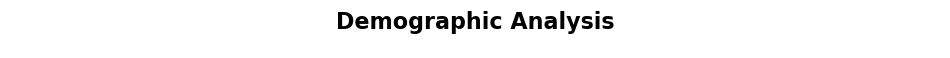

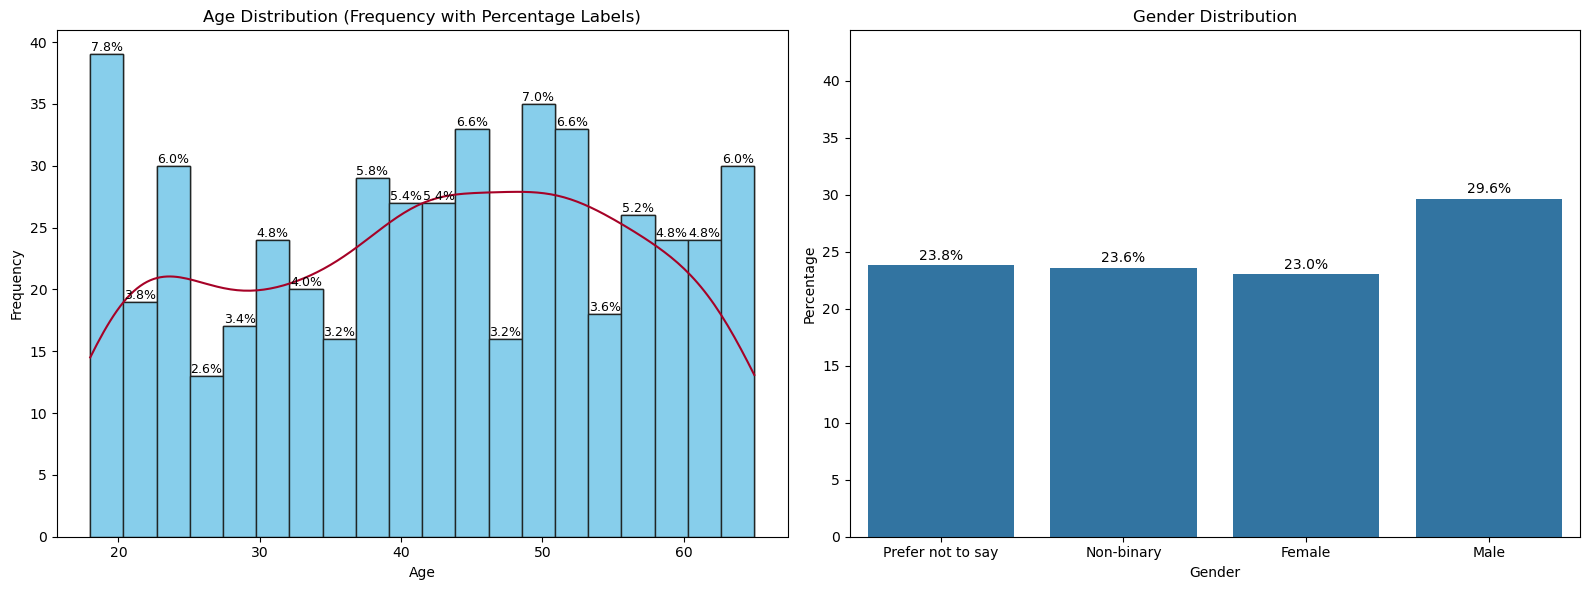

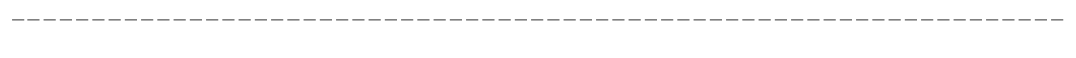

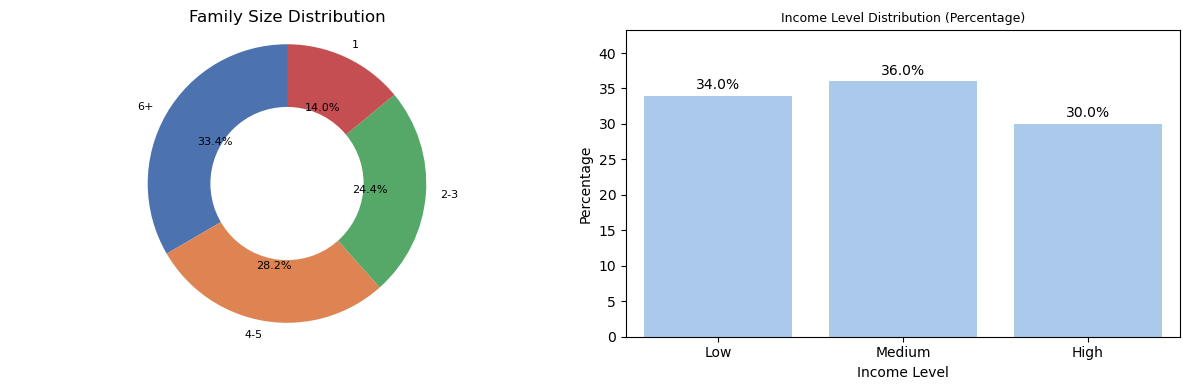

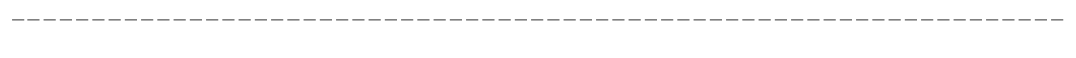

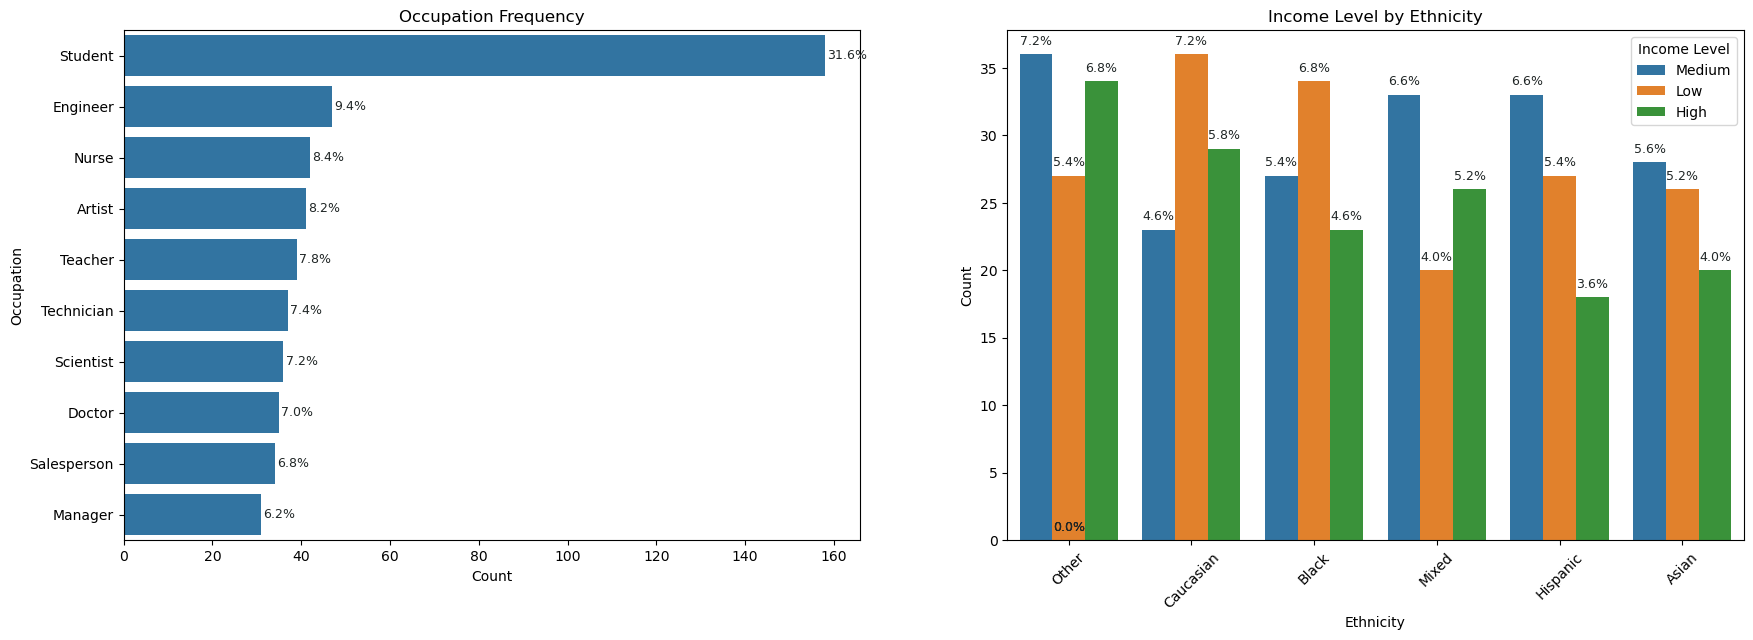

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Consumer_Insights_Dataset.xlsx'
sheet_name = 'Demographic Analysis'
df = pd.read_excel(file_path, sheet_name=sheet_name)

df = df.dropna()

plt.figure(figsize=(12, 0.5))
plt.text(0.5, 0.5, 'Demographic Analysis', fontsize=16, fontweight='bold', ha='center')
plt.axis('off')
plt.show()

# 1. Distribution of Age ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='#A60227')
counts, bins, patches = axes[0].hist(df['Age'], bins=20, edgecolor='#202626', color='skyblue')

total = sum(counts)
percentages = (counts / total) * 100

for count, patch, percentage in zip(counts, patches, percentages):
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width() / 2, height, f'{percentage:.1f}%', 
                 ha='center', va='bottom', fontsize=9)
    
axes[0].set_title('Age Distribution (Frequency with Percentage Labels)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# 2. Gender Distribution -----------------------------------------------------------------------------------------
ax = sns.countplot(x='Gender', data=df, ax=axes[1])
total_count = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_count) * 100
    p.set_height(percentage)  

max_percentage = max([p.get_height() for p in ax.patches])
ax.set_ylabel('Percentage')
ax.set_ylim(0, max_percentage * 1.5) 

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, f'{height:.1f}%', ha='center')

ax.set_title('Gender Distribution')
ax.set_xlabel('Gender')
plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

# Family Size trend
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

family_size_counts = df['FamilySize'].value_counts()
axes[0].pie(family_size_counts, labels=family_size_counts.index, autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette("deep", len(family_size_counts)), textprops={'fontsize': 8}, radius=1.0)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre_circle)

axes[0].set_title('Family Size Distribution')
axes[0].axis('equal')

total_count = len(df)
sns.countplot(x='Income Level', data=df, order=['Low', 'Medium', 'High'], color=sns.color_palette("pastel")[0], ax=axes[1])

for p in axes[1].patches:
    height = p.get_height()
    percentage = (height / total_count) * 100
    p.set_height(percentage)
    axes[1].text(p.get_x() + p.get_width() / 2, percentage + 0.5, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)

axes[1].set_ylabel('Percentage', fontsize=10)
axes[1].set_ylim(0, max([p.get_height() for p in axes[1].patches]) * 1.2)

axes[1].set_title('Income Level Distribution (Percentage)', fontsize=9)
axes[1].set_xlabel('Income Level', fontsize=10)

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

# Occupation Frequency and Income Level by Ethnicity-------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
occupation_counts = df['Occupation'].value_counts()
sns.countplot(y='Occupation', data=df, order=occupation_counts.index, ax=axes[0])
axes[0].set_title('Occupation Frequency')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Occupation')

total_occupation = len(df)
for p in axes[0].patches:
    width = p.get_width()
    percentage = (width / total_occupation) * 100
    axes[0].text(width + 0.5, p.get_y() + p.get_height() / 2, f'{percentage:.1f}%', ha='left', va='center', fontsize=9, color='#202626')

sns.countplot(x='Ethnicity', hue='Income Level', data=df, order=df['Ethnicity'].value_counts().index, ax=axes[1])
axes[1].set_title('Income Level by Ethnicity')
axes[1].set_xlabel('Ethnicity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

total_ethnicity = len(df)
for p in axes[1].patches:
    height = p.get_height()
    percentage = (height / total_ethnicity) * 100
    axes[1].text(p.get_x() + p.get_width() / 2, height + 0.5, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='#202626')

plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.1)
plt.show()



----------------------Purchasing Habits---------------------------------

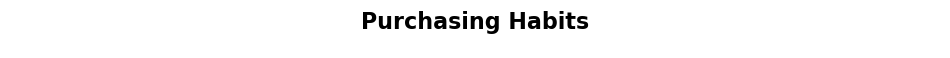

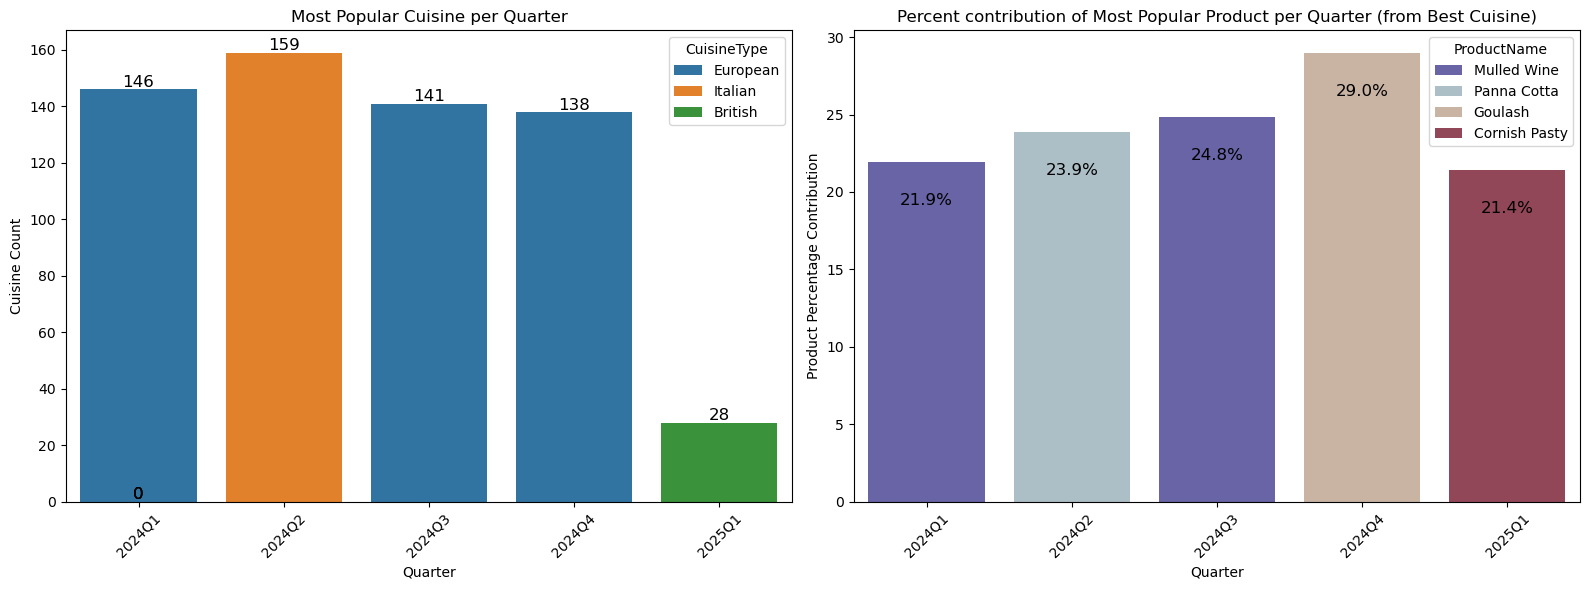

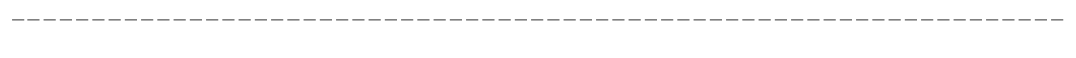

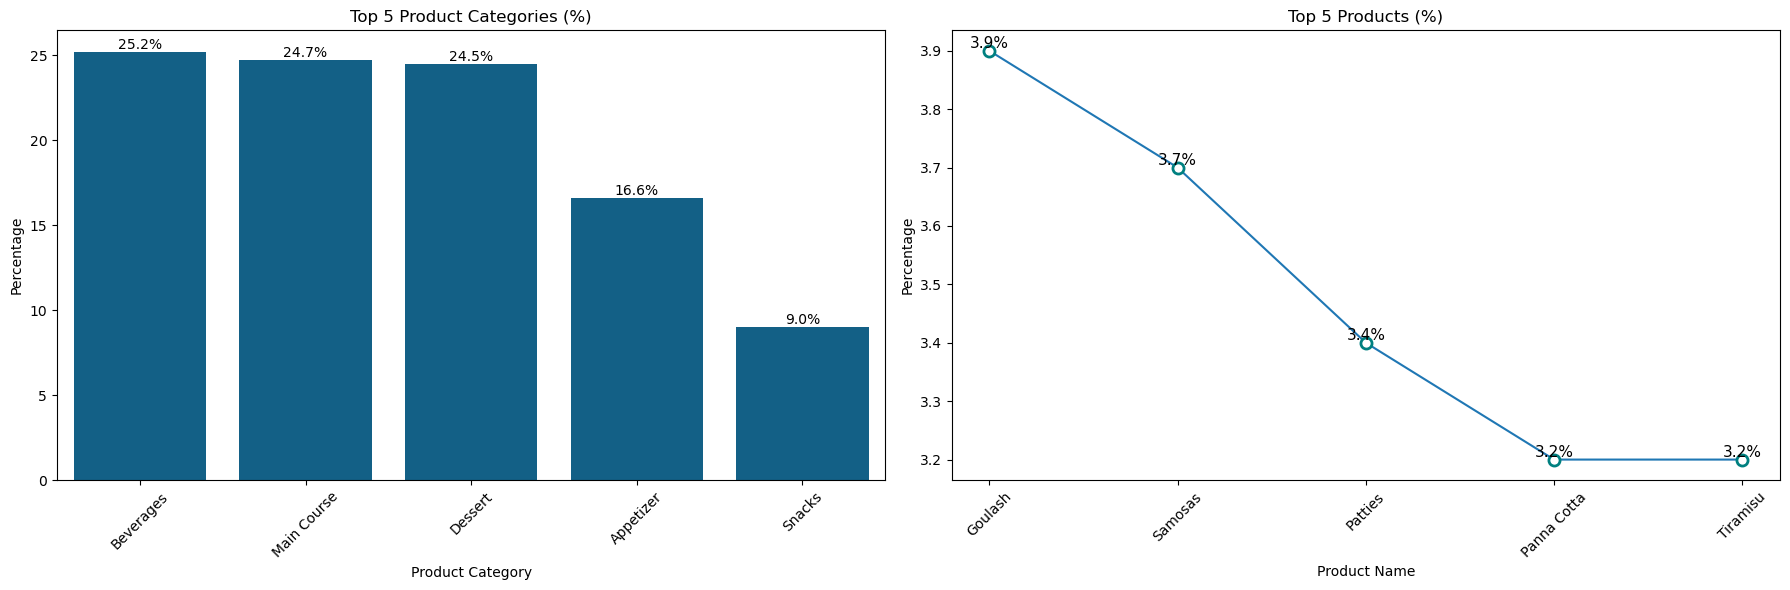

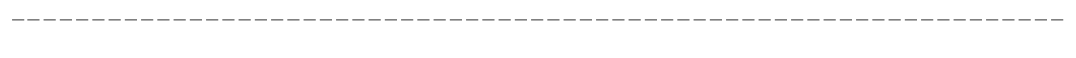

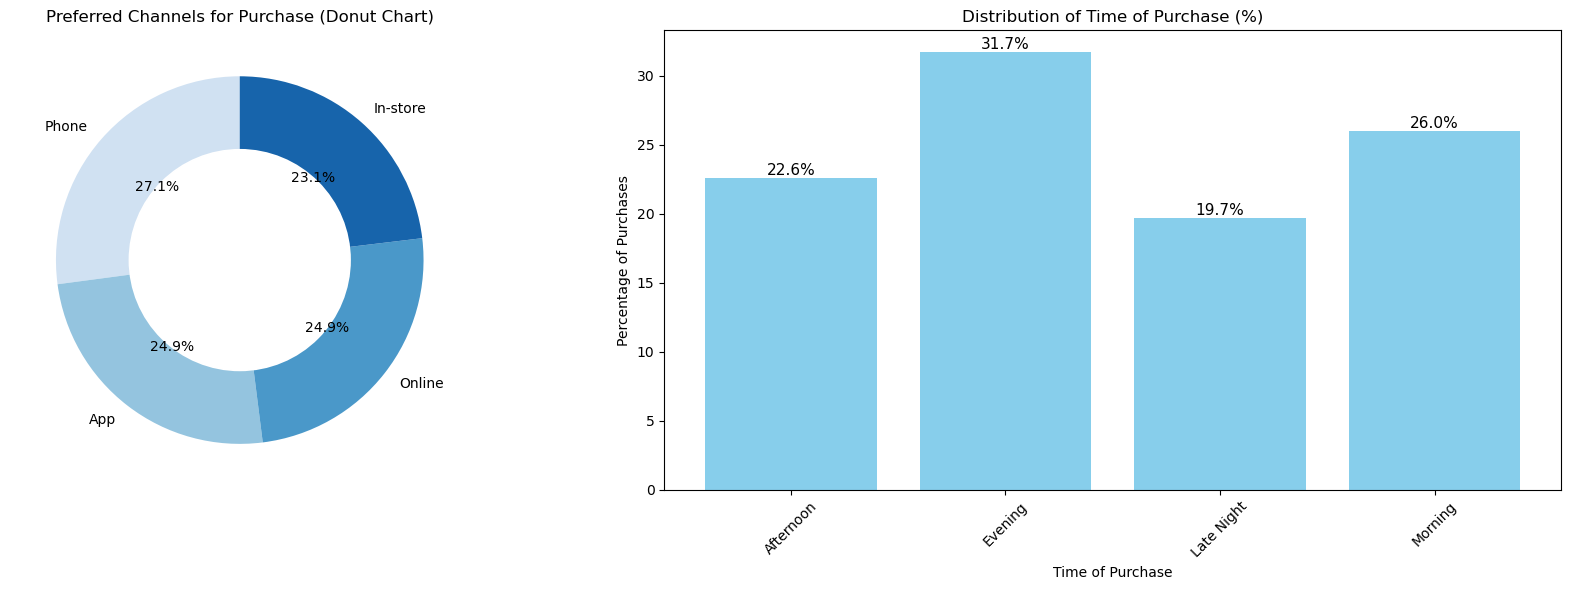

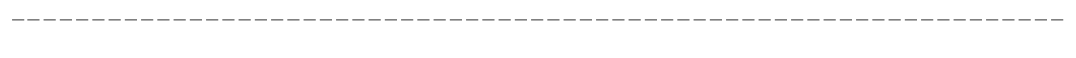

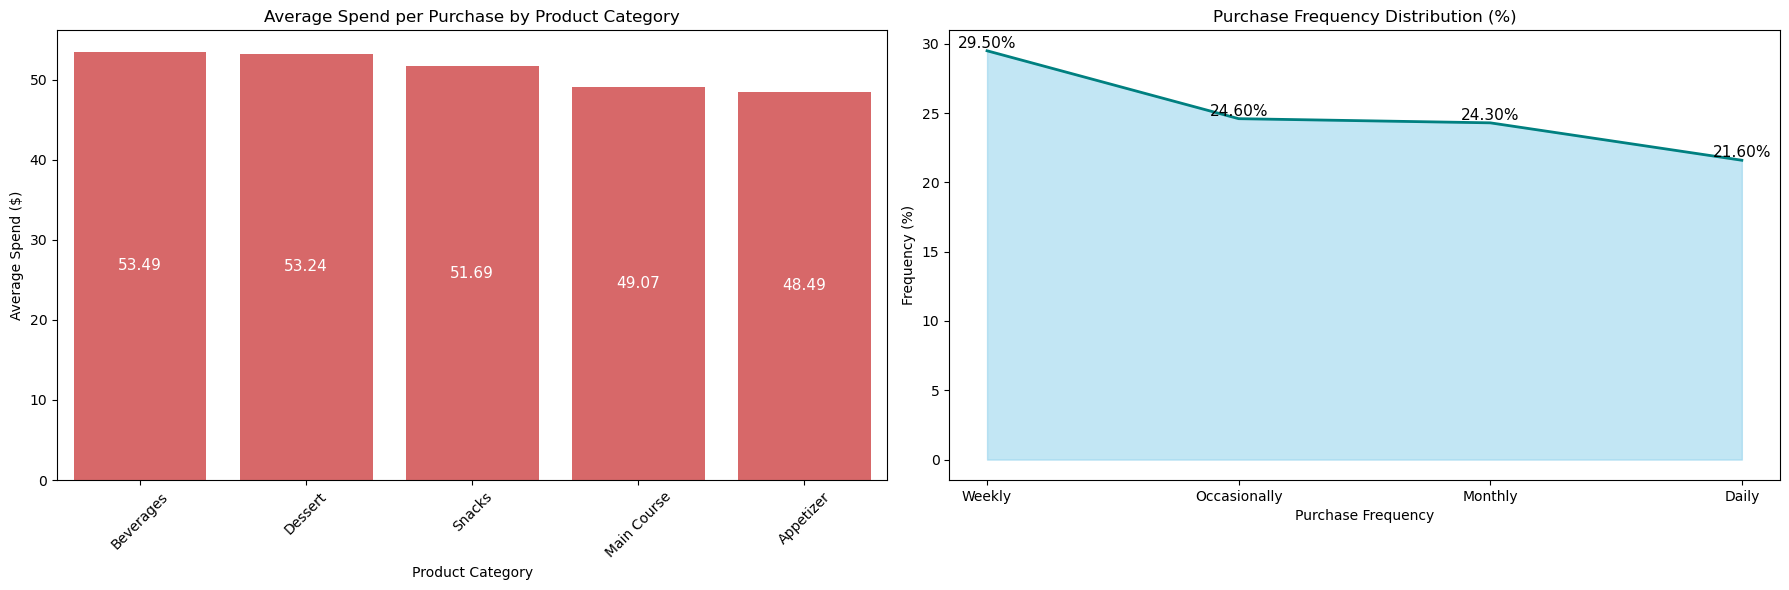

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Consumer_Insights_Dataset.xlsx'
sheet_name = 'Purchasing Habits'
df = pd.read_excel(file_path, sheet_name=sheet_name)
food_service_insights_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Superstore_Food_Services_Insights.xlsx'
food_service_insights = pd.read_excel(food_service_insights_path, sheet_name='Food Service Insights')

plt.figure(figsize=(12, 0.5))
plt.text(0.5, 0.5, 'Purchasing Habits', fontsize=16, fontweight='bold', ha='center')
plt.axis('off')
plt.show()

# Calculating Best cuisine and product quarterly-------------------------------------------------------------
# Merge Data on 'CustomerID'
merged_data = pd.merge(df, food_service_insights, on='CustomerID')

merged_data['OrderDate'] = pd.to_datetime(merged_data['OrderDate'])
merged_data['Quarter'] = merged_data['OrderDate'].dt.to_period('Q')

cuisine_popularity = merged_data.groupby(['Quarter', 'CuisineType']).size().reset_index(name='Count')
top_cuisines_per_quarter = cuisine_popularity.loc[cuisine_popularity.groupby('Quarter')['Count'].idxmax()]
best_product_data = pd.DataFrame()

# For each best cuisine, filter products and find the best product
for quarter in top_cuisines_per_quarter['Quarter'].unique():
    best_cuisine = top_cuisines_per_quarter[top_cuisines_per_quarter['Quarter'] == quarter]['CuisineType'].iloc[0]
    best_cuisine_data = merged_data[(merged_data['Quarter'] == quarter) & (merged_data['CuisineType'] == best_cuisine)]
    product_popularity = best_cuisine_data.groupby(['Quarter', 'CuisineType', 'ProductName']).size().reset_index(name='Count')
    total_sales_for_cuisine = product_popularity.groupby(['Quarter', 'CuisineType'])['Count'].transform('sum')
    top_product = product_popularity.loc[product_popularity.groupby(['Quarter', 'CuisineType'])['Count'].idxmax()]
    top_product['Percentage'] = (top_product['Count'] / total_sales_for_cuisine) * 100
    best_product_data = pd.concat([best_product_data, top_product])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Best Cuisine per Quarter
sns.barplot(data=top_cuisines_per_quarter, x='Quarter', y='Count', hue='CuisineType', dodge=False, ax=axes[0])
axes[0].set_title('Most Popular Cuisine per Quarter')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Cuisine Count')
axes[0].tick_params(axis='x', rotation=45)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     fontsize=12, color='black', 
                     xytext=(0, 5), textcoords='offset points')

product_palette = {product: color for product, color in zip(best_product_data['ProductName'].unique(), sns.color_palette("twilight_shifted", len(best_product_data['ProductName'].unique())))}

# Plot 2: Best Product per Quarter (from best cuisine)
sns.barplot(data=best_product_data, x='Quarter', y='Percentage', hue='ProductName', dodge=False, ax=axes[1], palette=product_palette)
axes[1].set_title('Percent contribution of Most Popular Product per Quarter (from Best Cuisine)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Product Percentage Contribution')
axes[1].tick_params(axis='x', rotation=45)

# Annotate the bars with the data labels
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height() - 2),  # Slightly inside the bar
                     ha='center', va='top',  # Align the text at the top of the bar (inside)
                     fontsize=12, color='black')  # White text for visibility

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

# Top 5 Product Categories - Bar Chart with Percentages

product_category_counts = df['ProductCategory'].value_counts(normalize=True).mul(100).round(2).head(5)
product_names_counts = df['ProductName'].value_counts(normalize=True).mul(100).round(2).head(5)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=product_category_counts.index, y=product_category_counts.values, ax=axes[0], color='#006699')
axes[0].set_title('Top 5 Product Categories (%)')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Product Category')
axes[0].set_xticks(range(len(product_category_counts.index)))  
axes[0].set_xticklabels(product_category_counts.index, rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='edge')

# Top 5 Product Names - Line Chart with Percentages
sns.lineplot(x=product_names_counts.index, y=product_names_counts.values, marker='o', markersize=8,
             markerfacecolor='white', markeredgecolor='teal', markeredgewidth=2, ax=axes[1])
axes[1].set_title('Top 5 Products (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Product Name')
axes[1].set_xticks(range(len(product_names_counts.index)))  
axes[1].set_xticklabels(product_names_counts.index, rotation=45)

for x, y in zip(product_names_counts.index, product_names_counts.values):
    axes[1].text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

# Preferred Channels and Time of Purchase Distribution with Percentages
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
channel_counts = df['PreferredChannel'].value_counts()
axes[0].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette("Blues", len(channel_counts)))

centre_circle = plt.Circle((0, 0), 0.60, color='white', fc='white', linewidth=1.25)
axes[0].add_artist(centre_circle)
axes[0].set_title('Preferred Channels for Purchase (Donut Chart)')

purchase_counts = df['TimeOfPurchase'].value_counts().sort_index()
purchase_percentages = (purchase_counts / purchase_counts.sum()) * 100

axes[1].bar(purchase_percentages.index, purchase_percentages.values, color='skyblue')
axes[1].set_title('Distribution of Time of Purchase (%)')
axes[1].set_ylabel('Percentage of Purchases')
axes[1].set_xlabel('Time of Purchase')
axes[1].set_xticks(range(len(purchase_percentages.index)))  
axes[1].set_xticklabels(purchase_percentages.index, rotation=45)

for x, y in zip(purchase_percentages.index, purchase_percentages.values):
    axes[1].text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

avg_spend_per_category = df.groupby('ProductCategory')['AverageSpendPerPurchase'].mean().sort_values(ascending=False)
sns.barplot(x=avg_spend_per_category.index, y=avg_spend_per_category.values, color='#E95657', ax=axes[0])
axes[0].set_title('Average Spend per Purchase by Product Category')
axes[0].set_ylabel('Average Spend ($)')
axes[0].set_xlabel('Product Category')
axes[0].set_xticks(range(len(avg_spend_per_category)))
axes[0].set_xticklabels(avg_spend_per_category.index, rotation=45)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height:.2f}', 
                     (p.get_x() + p.get_width() / 2., height / 2), 
                     ha='center', va='center', fontsize=11, color='white')

purchase_freq_counts = df['PurchaseFrequency'].value_counts(normalize=True).mul(100).round(2)
axes[1].fill_between(purchase_freq_counts.index, purchase_freq_counts.values, color='skyblue', alpha=0.5)
axes[1].plot(purchase_freq_counts.index, purchase_freq_counts.values, color='teal', lw=2)

axes[1].set_title('Purchase Frequency Distribution (%)')
axes[1].set_xlabel('Purchase Frequency')
axes[1].set_ylabel('Frequency (%)')

for x, y in zip(purchase_freq_counts.index, purchase_freq_counts.values):
    axes[1].text(x, y, f'{y:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()



----------------------New Food Options --------------------

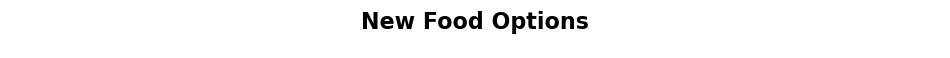

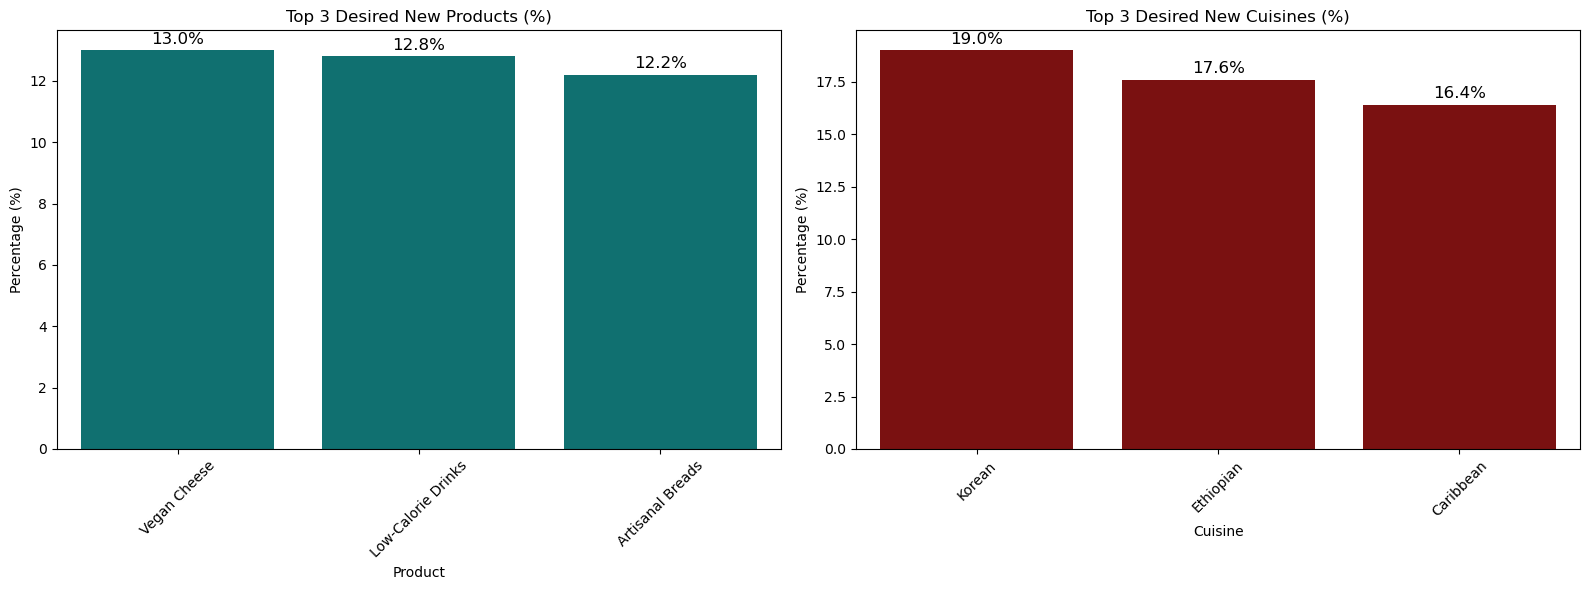

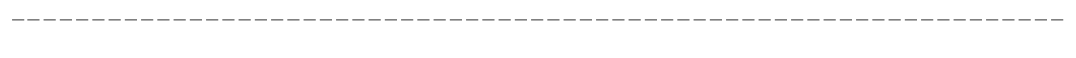

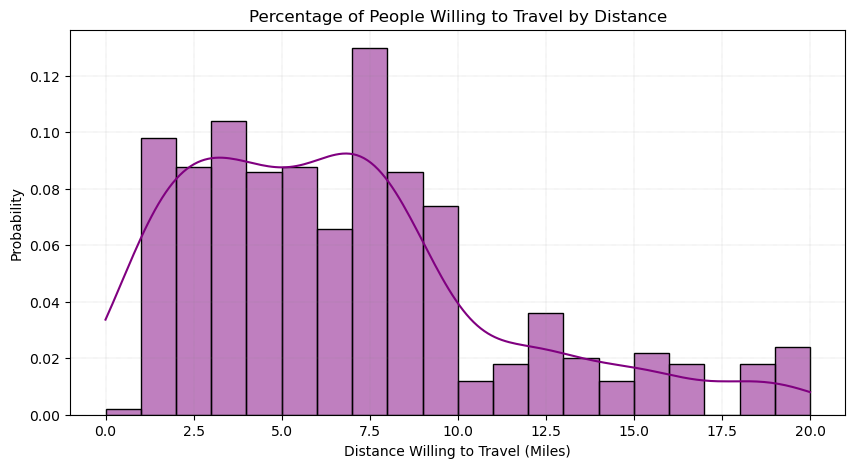

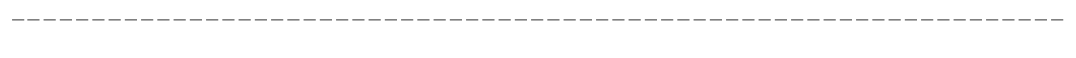

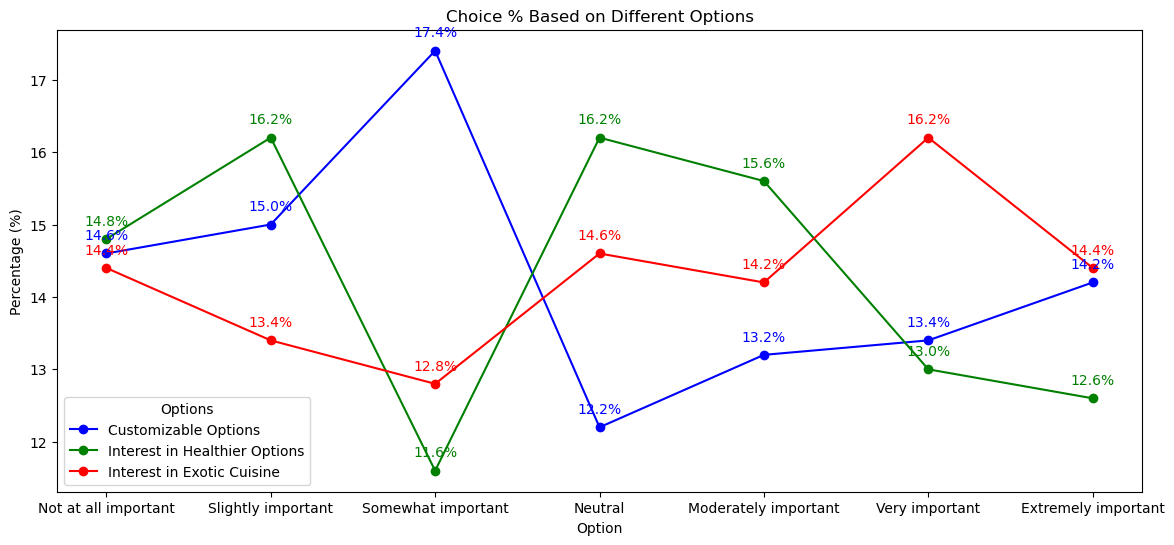

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Consumer_Insights_Dataset.xlsx'
sheet_name = 'New Food Options'
df = pd.read_excel(file_path, sheet_name=sheet_name)

plt.figure(figsize=(12, 0.5))
plt.text(0.5, 0.5, 'New Food Options', fontsize=16, fontweight='bold', ha='center')
plt.axis('off')
plt.show()

# 1. Top 3 Desired New Products (as %)
top_3_products = df['DesiredNewProducts'].value_counts(normalize=True).nlargest(3) * 100

# 2. Top 3 Desired New Cuisines (as %)
top_3_cuisines = df['NewCuisineSuggestions'].value_counts(normalize=True).nlargest(3) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_3_products.index, y=top_3_products.values, color='teal', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 8),
                     textcoords='offset points')
axes[0].set_title('Top 3 Desired New Products (%)')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=top_3_cuisines.index, y=top_3_cuisines.values, color='darkred', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 8),
                     textcoords='offset points')
axes[1].set_title('Top 3 Desired New Cuisines (%)')
axes[1].set_xlabel('Cuisine')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

# 3. Percentage of People Willing to Travel by Distance
df['DistanceWillingToTravel'] = pd.to_numeric(df['DistanceWillingToTravel'], errors='coerce')
plt.figure(figsize=(10, 5))
sns.histplot(df['DistanceWillingToTravel'], kde=True, color='purple', bins=20, stat='probability')

plt.grid(True, linestyle=':', color='grey', linewidth=0.25)
plt.title('Percentage of People Willing to Travel by Distance')
plt.xlabel('Distance Willing to Travel (Miles)')
plt.ylabel('Probability')
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

importance_order = [
    "Not at all important", 
    "Slightly important", 
    "Somewhat important", 
    "Neutral", 
    "Moderately important", 
    "Very important", 
    "Extremely important"
]

df['CustomizableOptions'] = pd.Categorical(df['CustomizableOptions'], categories=importance_order, ordered=True)
df['InterestInHealthierOptions'] = pd.Categorical(df['InterestInHealthierOptions'], categories=importance_order, ordered=True)
df['InterestInExoticCuisine'] = pd.Categorical(df['InterestInExoticCuisine'], categories=importance_order, ordered=True)

plt.figure(figsize=(14, 6))

customizable_options = df['CustomizableOptions'].value_counts(normalize=True).sort_index(ascending=True) * 100
interest_healthier = df['InterestInHealthierOptions'].value_counts(normalize=True).sort_index(ascending=True) * 100
interest_exotic_cuisine = df['InterestInExoticCuisine'].value_counts(normalize=True).sort_index(ascending=True) * 100

plt.plot(customizable_options.index, customizable_options.values, label='Customizable Options', marker='o', color='blue')
plt.plot(interest_healthier.index, interest_healthier.values, label='Interest in Healthier Options', marker='o', color='green')
plt.plot(interest_exotic_cuisine.index, interest_exotic_cuisine.values, label='Interest in Exotic Cuisine', marker='o', color='red')

for i in range(len(customizable_options)):
    plt.annotate(f'{customizable_options.values[i]:.1f}%', 
                 (customizable_options.index[i], customizable_options.values[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='blue')

for i in range(len(interest_healthier)):
    plt.annotate(f'{interest_healthier.values[i]:.1f}%', 
                 (interest_healthier.index[i], interest_healthier.values[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='green')

for i in range(len(interest_exotic_cuisine)):
    plt.annotate(f'{interest_exotic_cuisine.values[i]:.1f}%', 
                 (interest_exotic_cuisine.index[i], interest_exotic_cuisine.values[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='red')

plt.title('Choice % Based on Different Options')
plt.xlabel('Option')
plt.ylabel('Percentage (%)')
plt.legend(title='Options')

plt.show()


-----------------Sustainability Preferences-------------------------

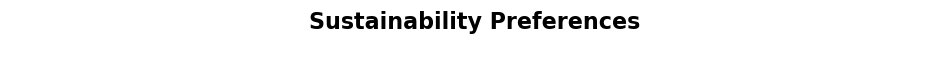

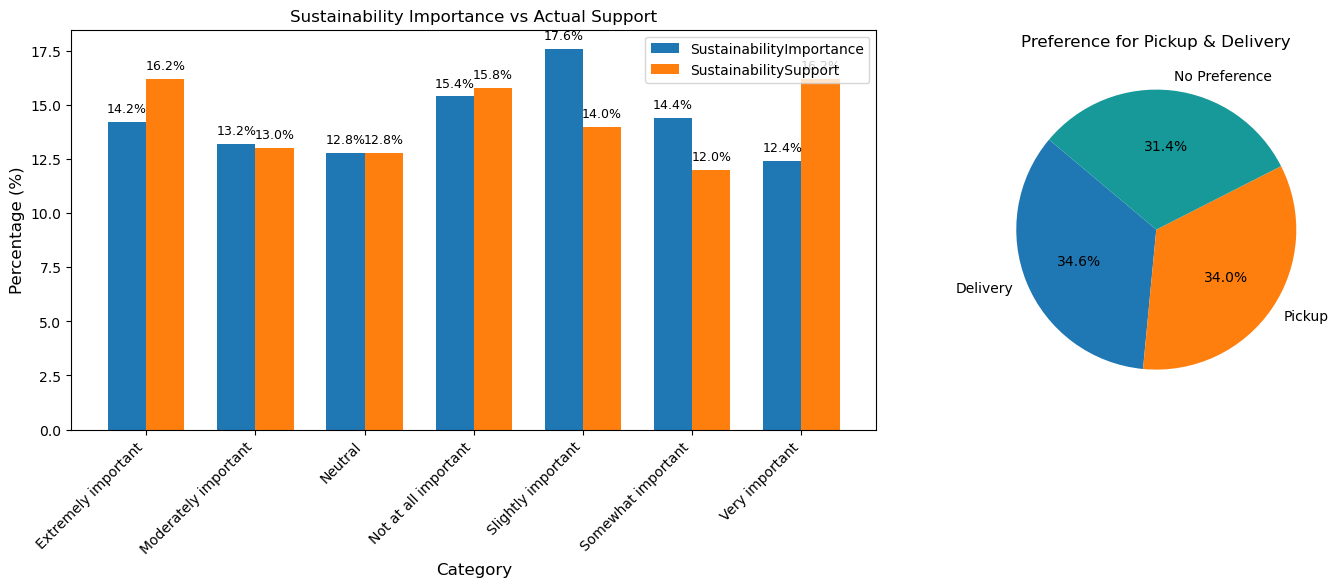

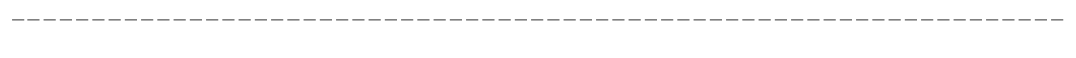

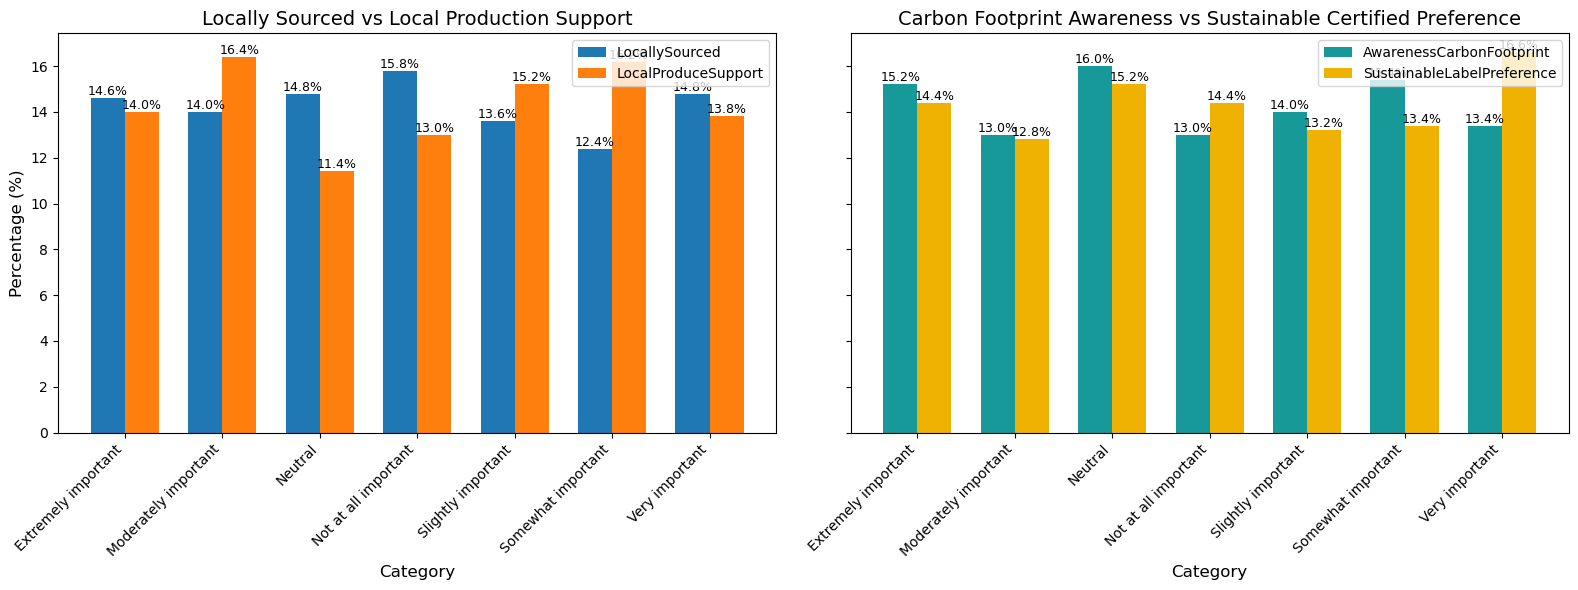

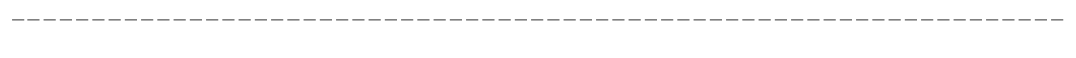

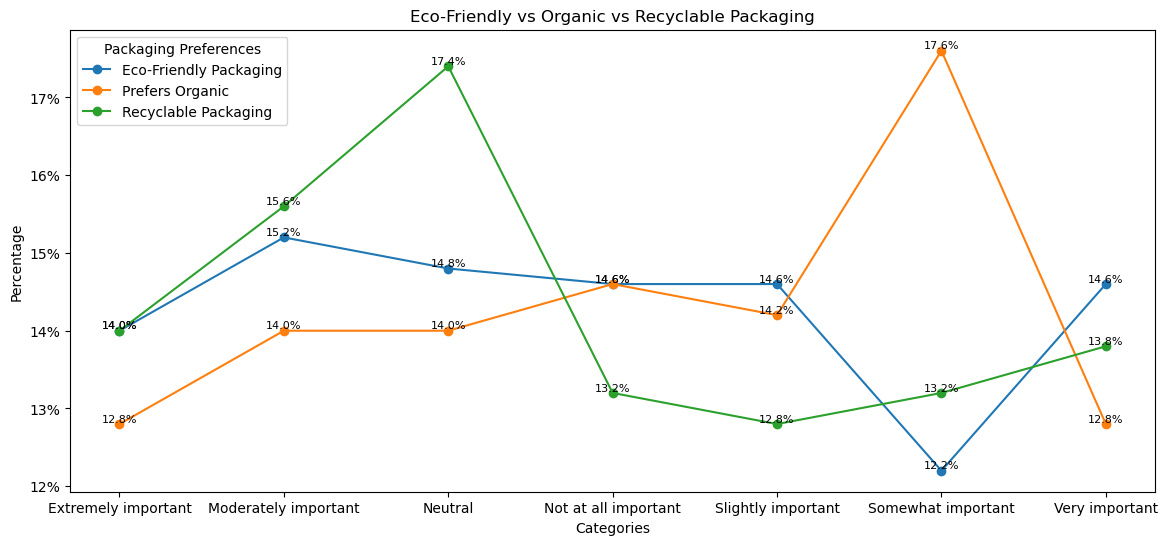

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# File path and sheet name
file_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Consumer_Insights_Dataset.xlsx'
sheet_name = 'Sustainability Preferences'

# Load data
df = pd.read_excel(file_path, sheet_name=sheet_name)

plt.figure(figsize=(12, 0.5))
plt.text(0.5, 0.5, 'Sustainability Preferences', fontsize=16, fontweight='bold', ha='center')
plt.axis('off')
plt.show()

# 1. SustainabilityImportance vs Sustainability Support

importance_counts = df['SustainabilityImportance'].value_counts(normalize=True) * 100
importance_df = importance_counts.reset_index()
importance_df.columns = ['Category', 'SustainabilityImportance']

if 'SustainabilitySupport' in df.columns:
    support_counts = df['SustainabilitySupport'].value_counts(normalize=True) * 100
    support_df = support_counts.reset_index()
    support_df.columns = ['Category', 'SustainabilitySupport']
    combined_df = pd.merge(importance_df, support_df, on='Category', how='outer')
else:
    combined_df = importance_df.copy()
    combined_df['SustainabilitySupport'] = [np.nan] * len(combined_df)

combined_df = combined_df.sort_values(by='Category')

def add_data_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

fig = plt.figure(figsize=(14, 5))
grid = plt.GridSpec(1, 3, wspace=0.3)

ax1 = fig.add_subplot(grid[0, 0:2])  
x = np.arange(len(combined_df['Category']))
bar_width = 0.35

bars1 = ax1.bar(x - bar_width / 2, combined_df['SustainabilityImportance'], bar_width, label='SustainabilityImportance', color='#1f77b4')
bars2 = ax1.bar(x + bar_width / 2, combined_df['SustainabilitySupport'], bar_width, label='SustainabilitySupport', color='#ff7f0e')

ax1.set_title('Sustainability Importance vs Actual Support', fontsize=12)
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(combined_df['Category'], rotation=45, ha='right', fontsize=10)
ax1.legend(fontsize=10)
#ax1.grid(axis='y', linestyle=':', alpha=0.7)

add_data_labels(ax1, bars1)
add_data_labels(ax1, bars2)

# Pickup or Delivery Preference
ax2 = fig.add_subplot(grid[0, 2]) 
pickup_delivery_counts = df['PickupOrDeliveryPreferred'].value_counts(normalize=True) * 100
pickup_delivery_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=['#1f77b4', '#ff7f0e','#169998'],
    ax=ax2
)

ax2.set_title('Preference for Pickup & Delivery', fontsize=12)
ax2.set_ylabel('')  # Remove the y-axis label for the pie chart

fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3)
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

def calculate_percentages(df, column):
    counts = df[column].value_counts(normalize=True) * 100
    df_counts = counts.reset_index()
    df_counts.columns = ['Category', column]
    return df_counts

def add_data_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height, 
            f'{height:.1f}%', 
            ha='center', 
            va='bottom', 
            fontsize=9
        )

def create_combined_charts(df, col1_1, col1_2, col2_1, col2_2, title1, title2):
    col1_df1 = calculate_percentages(df, col1_1)
    col1_df2 = calculate_percentages(df, col1_2)
    combined_df1 = pd.merge(col1_df1, col1_df2, on='Category', how='outer').fillna(0).sort_values(by='Category')

    col2_df1 = calculate_percentages(df, col2_1)
    col2_df2 = calculate_percentages(df, col2_2)
    combined_df2 = pd.merge(col2_df1, col2_df2, on='Category', how='outer').fillna(0).sort_values(by='Category')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    x1 = np.arange(len(combined_df1['Category']))
    bar_width = 0.35
    bars1 = axes[0].bar(x1 - bar_width / 2, combined_df1[col1_1], bar_width, label=col1_1, color='#1f77b4')
    bars2 = axes[0].bar(x1 + bar_width / 2, combined_df1[col1_2], bar_width, label=col1_2, color='#ff7f0e')
    axes[0].set_title(title1, fontsize=14)
    axes[0].set_xlabel('Category', fontsize=12)
    axes[0].set_ylabel('Percentage (%)', fontsize=12)
    axes[0].set_xticks(x1)
    axes[0].set_xticklabels(combined_df1['Category'], rotation=45, ha='right', fontsize=10)
    axes[0].legend(fontsize=10)
   # axes[0].grid(axis='y', linestyle=':', alpha=0.7)
    add_data_labels(axes[0], bars1)
    add_data_labels(axes[0], bars2)

    x2 = np.arange(len(combined_df2['Category']))
    bars3 = axes[1].bar(x2 - bar_width / 2, combined_df2[col2_1], bar_width, label=col2_1, color='#169998')
    bars4 = axes[1].bar(x2 + bar_width / 2, combined_df2[col2_2], bar_width, label=col2_2, color='#F0B202')
    axes[1].set_title(title2, fontsize=14)
    axes[1].set_xlabel('Category', fontsize=12)
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(combined_df2['Category'], rotation=45, ha='right', fontsize=10)
    axes[1].legend(fontsize=10)
    #axes[1].grid(axis='y', linestyle=':', alpha=0.7)
    add_data_labels(axes[1], bars3)
    add_data_labels(axes[1], bars4)
    plt.tight_layout()
    plt.show()

create_combined_charts(
    df,
    col1_1='LocallySourced',
    col1_2='LocalProduceSupport',
    col2_1='AwarenessCarbonFootprint',
    col2_2='SustainableLabelPreference',
    title1='Locally Sourced vs Local Production Support',
    title2='Carbon Footprint Awareness vs Sustainable Certified Preference'
)

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color= 'grey')
plt.axis('off')
plt.show()

plt.figure(figsize=(14, 6))
ax = df['EcoFriendlyPackaging'].value_counts(normalize=True).sort_index().plot(kind='line', marker='o', label='Eco-Friendly Packaging')
for x, y in enumerate(df['EcoFriendlyPackaging'].value_counts(normalize=True).sort_index()):
    ax.text(x, y, f'{y*100:.1f}%', color='black', ha='center', va='bottom', fontsize=8)

ax = df['PrefersOrganic'].value_counts(normalize=True).sort_index().plot(kind='line', marker='o', label='Prefers Organic')
for x, y in enumerate(df['PrefersOrganic'].value_counts(normalize=True).sort_index()):
    ax.text(x, y, f'{y*100:.1f}%', color='black', ha='center', va='bottom', fontsize=8)

ax = df['RecyclablePackaging'].value_counts(normalize=True).sort_index().plot(kind='line', marker='o', label='Recyclable Packaging')
for x, y in enumerate(df['RecyclablePackaging'].value_counts(normalize=True).sort_index()):
    ax.text(x, y, f'{y*100:.1f}%', color='black', ha='center', va='bottom', fontsize=8)

plt.title('Eco-Friendly vs Organic vs Recyclable Packaging')
plt.xlabel('Categories')
plt.ylabel('Percentage')

formatter = FuncFormatter(lambda x, _: f'{x*100:.0f}%')
ax.yaxis.set_major_formatter(formatter)
plt.legend(title='Packaging Preferences')
plt.show()

-------------------Satisfaction Trend-----------------------

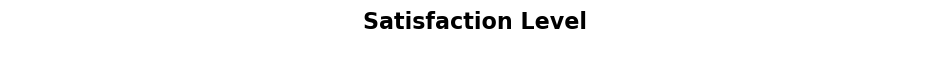

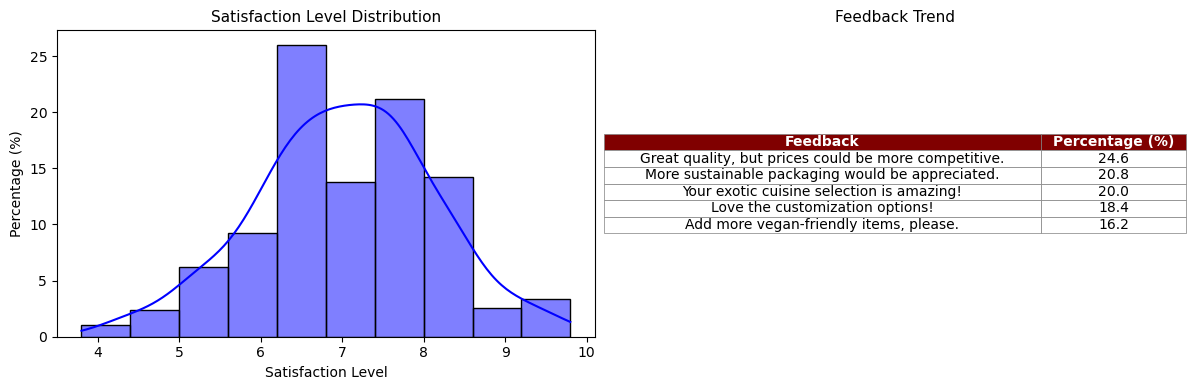

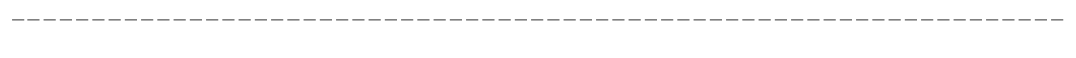

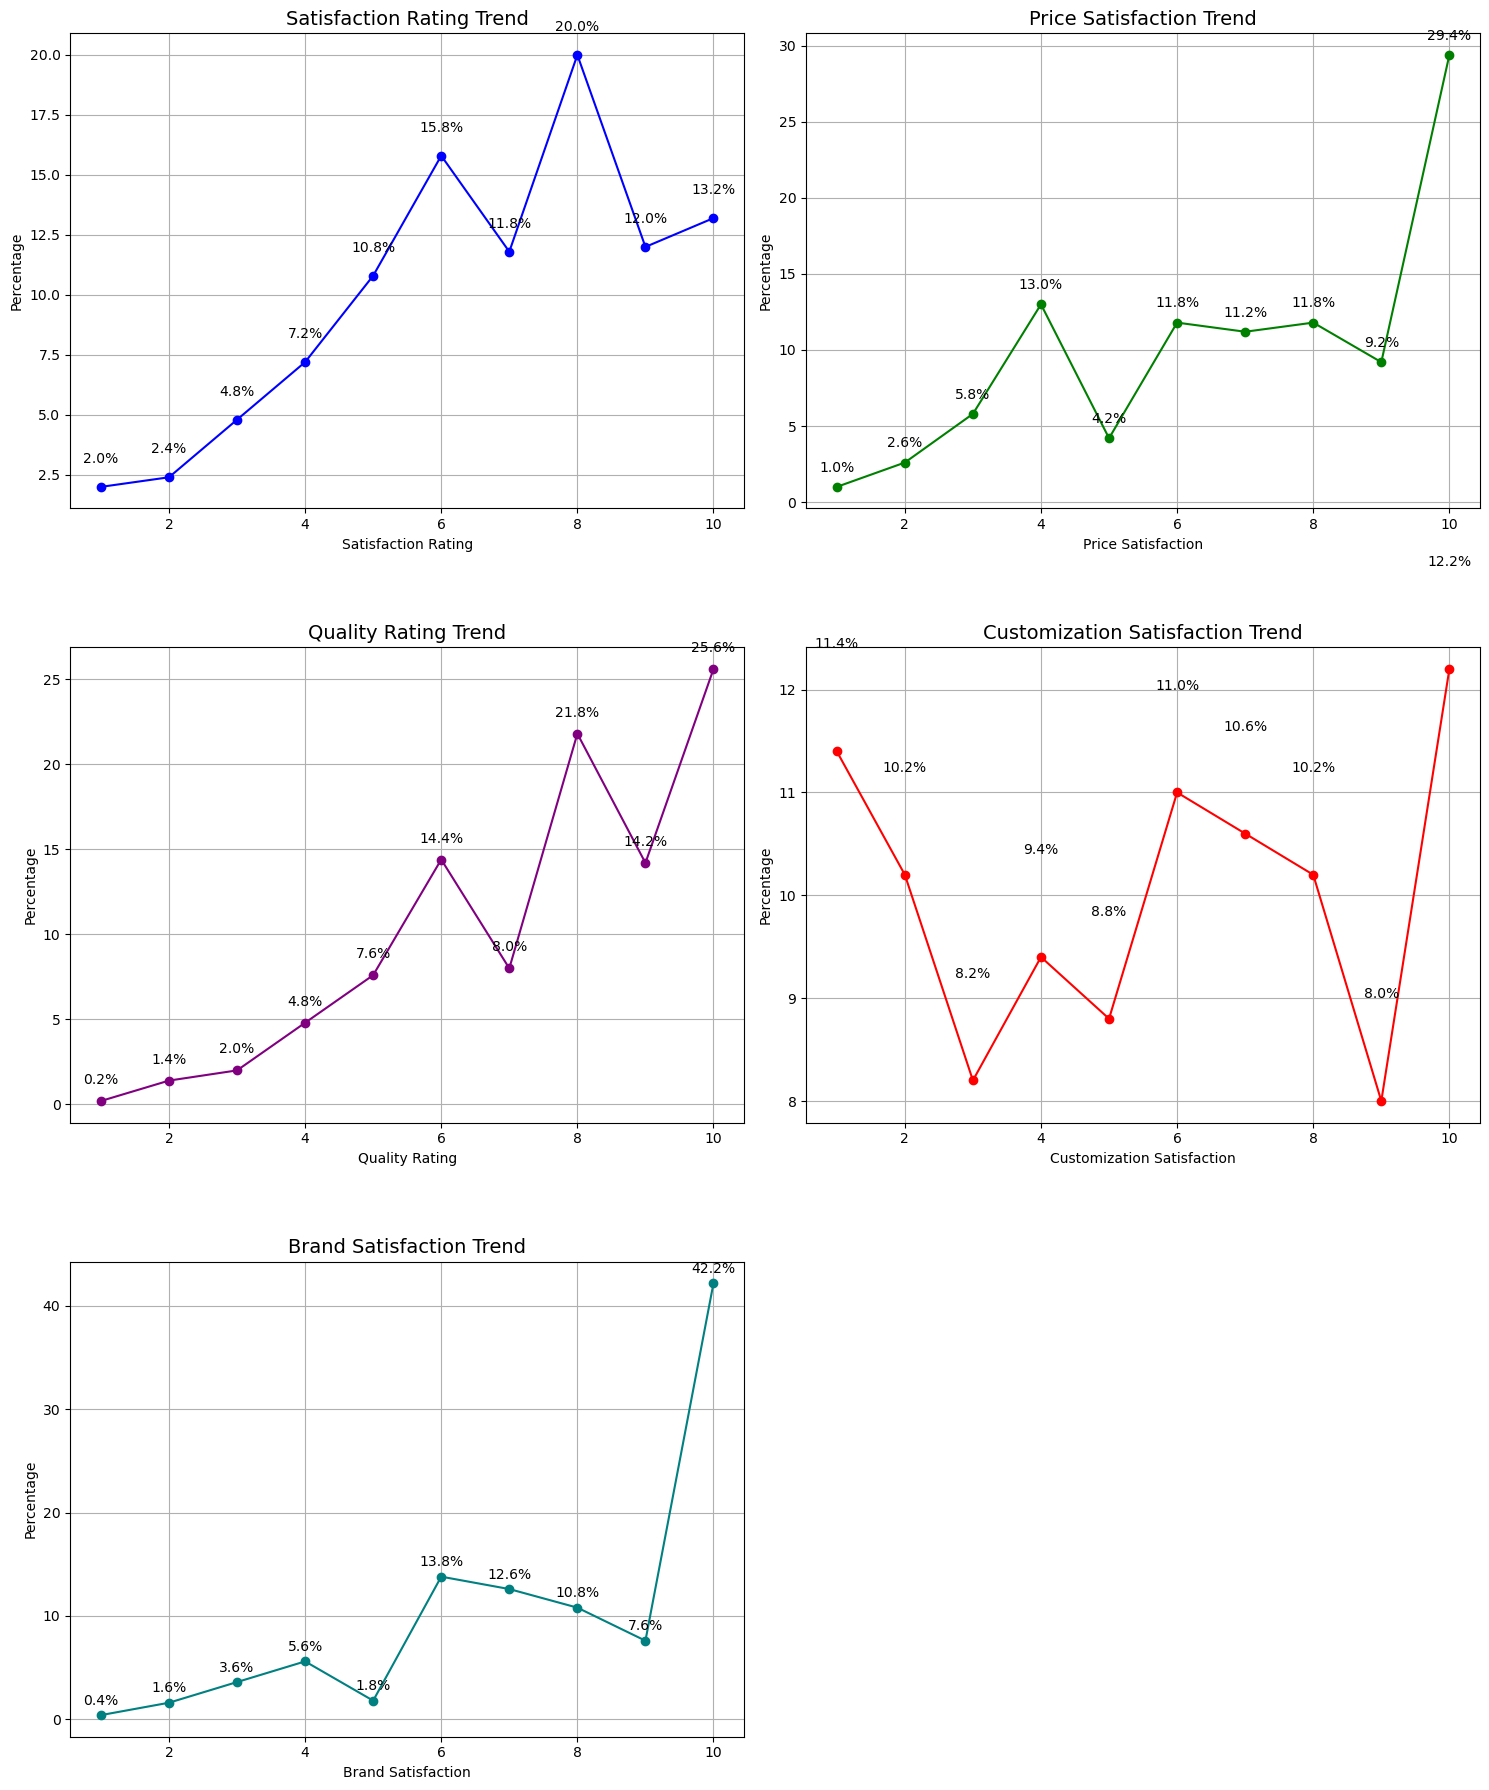

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'D:\Freelancing_Projects\13.Power BI and Pyhton Dashboard\Consumer_Insights_Dataset.xlsx'
sheet_name = 'Satisfaction'
df = pd.read_excel(file_path, sheet_name=sheet_name)

df['SatisfactionLevel'] =df[['SatisfactionRating','BrandSatisfaction','QualityRating','PriceSatisfaction','CustomizationSatisfaction']].mean(axis=1)

feedback_counts = df['Feedback'].value_counts(normalize=True) * 100
feedback_table = pd.DataFrame({
    'Feedback': feedback_counts.index,
    'Percentage (%)': feedback_counts.values
})

plt.figure(figsize=(12, 0.5))
plt.text(0.5, 0.5, 'Satisfaction Level', fontsize=16, fontweight='bold', ha='center')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})

sns.histplot(df['SatisfactionLevel'], kde=True, color='blue', bins=10, stat="percent", ax=axes[0])
axes[0].set_title('Satisfaction Level Distribution', fontsize=11)
axes[0].set_xlabel('Satisfaction Level')
axes[0].set_ylabel('Percentage (%)')

axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(
    cellText=feedback_table.values,
    colLabels=feedback_table.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1])
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('grey')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor('#800000')
        cell.set_text_props(color='white', weight='bold')
axes[1].set_title('Feedback Trend', fontsize=11)

plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 0.5))
plt.text(0, 0.6, '−' * 65, fontsize=14, ha='left', color='grey')
plt.axis('off')
plt.show()

def calculate_trend(data, column):
    trend = data[column].value_counts(normalize=True).sort_index() * 100
    return trend

fig, axs = plt.subplots(3, 2, figsize=(15, 18))

satisfaction_trend = calculate_trend(df, 'SatisfactionRating')
axs[0, 0].plot(satisfaction_trend.index, satisfaction_trend.values, marker='o', color='blue')
axs[0, 0].set_title('Satisfaction Rating Trend', fontsize=14)
axs[0, 0].set_xlabel('Satisfaction Rating')
axs[0, 0].set_ylabel('Percentage')
axs[0, 0].grid()

for x, y in zip(satisfaction_trend.index, satisfaction_trend.values):
    axs[0, 0].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10)

price_trend = calculate_trend(df, 'PriceSatisfaction')
axs[0, 1].plot(price_trend.index, price_trend.values, marker='o', color='green')
axs[0, 1].set_title('Price Satisfaction Trend', fontsize=14)
axs[0, 1].set_xlabel('Price Satisfaction')
axs[0, 1].set_ylabel('Percentage')
axs[0, 1].grid()

for x, y in zip(price_trend.index, price_trend.values):
    axs[0, 1].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10)

quality_trend = calculate_trend(df, 'QualityRating')
axs[1, 0].plot(quality_trend.index, quality_trend.values, marker='o', color='purple')
axs[1, 0].set_title('Quality Rating Trend', fontsize=14)
axs[1, 0].set_xlabel('Quality Rating')
axs[1, 0].set_ylabel('Percentage')
axs[1, 0].grid()

for x, y in zip(quality_trend.index, quality_trend.values):
    axs[1, 0].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10)

customization_trend = calculate_trend(df, 'CustomizationSatisfaction')
axs[1, 1].plot(customization_trend.index, customization_trend.values, marker='o', color='red')
axs[1, 1].set_title('Customization Satisfaction Trend', fontsize=14)
axs[1, 1].set_xlabel('Customization Satisfaction')
axs[1, 1].set_ylabel('Percentage')
axs[1, 1].grid()

for x, y in zip(customization_trend.index, customization_trend.values):
    axs[1, 1].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10)

brand_trend = calculate_trend(df, 'BrandSatisfaction')
axs[2, 0].plot(brand_trend.index, brand_trend.values, marker='o', color='teal')
axs[2, 0].set_title('Brand Satisfaction Trend', fontsize=14)
axs[2, 0].set_xlabel('Brand Satisfaction')
axs[2, 0].set_ylabel('Percentage')
axs[2, 0].grid()

for x, y in zip(brand_trend.index, brand_trend.values):
    axs[2, 0].text(x, y + 1, f'{y:.1f}%', ha='center', fontsize=10)

axs[2, 1].axis('off')

plt.tight_layout()
plt.show()
